In [2]:
#import packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [3]:
#access databases
HR_data = pd.read_csv("HR_comma_sep.csv", parse_dates = True)
print(HR_data)


       satisfaction_level  last_evaluation  number_project  \
0                    0.38             0.53               2   
1                    0.80             0.86               5   
2                    0.11             0.88               7   
3                    0.72             0.87               5   
4                    0.37             0.52               2   
...                   ...              ...             ...   
14994                0.40             0.57               2   
14995                0.37             0.48               2   
14996                0.37             0.53               2   
14997                0.11             0.96               6   
14998                0.37             0.52               2   

       average_montly_hours  time_spend_company  Work_accident  left  \
0                       157                   3              0     1   
1                       262                   6              0     1   
2                       272            

left
0    11428
1     3571
Name: left, dtype: int64
             count  percentage_left
salary left                        
high   0      1155         0.933711
       1        82         0.066289
low    0      5144         0.703116
       1      2172         0.296884
medium 0      5129         0.795687
       1      1317         0.204313
                         count  percentage_left
time_spend_company left                        
2                  0      3191         0.983662
                   1        53         0.016338
3                  0      4857         0.753841
                   1      1586         0.246159
4                  0      1667         0.651936
                   1       890         0.348064
5                  0       640         0.434487
                   1       833         0.565513
6                  0       509         0.708914
                   1       209         0.291086
7                  0       188         1.000000
8                  0       162      

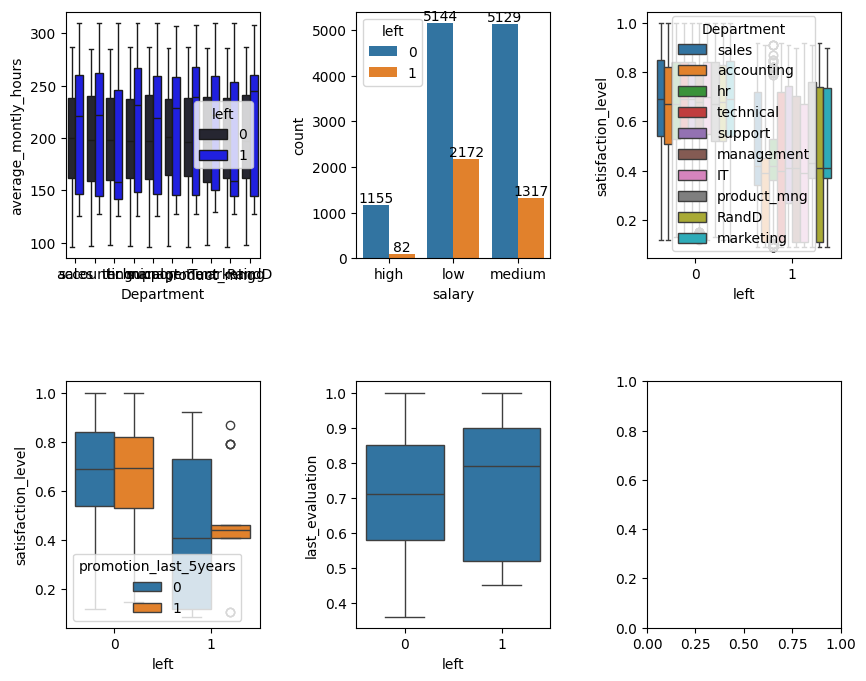

In [4]:
#check entire table for cleaning and transformation purposes
#print(HR_data.head(10))
#print(HR_data.isna().sum(axis=0))
#absolutely clean dataset. No missing nas

#wanna check if number of people who left and those who didnt is imbalanced
HR_left_grp = HR_data.groupby('left')['left'].agg('count')
print(HR_left_grp)

fig, ax = plt.subplots(2,3, figsize=(10,8))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
#check for outliers and weird values per each column
##continuous data applicable for boxplots and outliers sensing.
"""Averge_monthly_hours - means can just create one boxplot to check outliers"""
boxey = sns.boxplot(HR_data,x = "Department", y ='average_montly_hours', palette='dark:blue', hue='left', ax=ax[0,0])


#create a groupby dataset that allows us to get the counts of people who left and stayed based on their salary category
HR_grp_salary = HR_data.groupby(['salary', 'left'])['left'].agg(['count'])
HR_count_salary = HR_data.groupby(['salary'])['salary'].count()
HR_grp_salary['percentage_left'] = HR_grp_salary['count'] / HR_count_salary
print(HR_grp_salary)
#create a barplot to check the amount of stayers/leavers per work salary catagorization
barry= sns.barplot(HR_grp_salary, x='salary',y='count', hue='left', ax=ax[0,1])
for container in barry.containers:
    barry.bar_label(container)

#create a boxplot to check satisfaction level and evaluation level for left and stayed employees
##Maybe it will be a good reference for engagement and competence
boxey2 = sns.boxplot(HR_data, y='satisfaction_level', x='left', hue='promotion_last_5years', ax=ax[1,0])
boxey3 = sns.boxplot(HR_data, y='last_evaluation', x='left', ax=ax[1,1])

#check if time spent in company affects company leave rate
HR_grp_yrs = HR_data.groupby(['time_spend_company', 'left'])['left'].agg(['count'])
HR_count_yrs = HR_data.groupby(['time_spend_company'])['left'].agg('count')
HR_grp_yrs['percentage_left'] = HR_grp_yrs['count']/ HR_count_yrs
print(HR_grp_yrs)


#check if work accident correlates with leaving - means if work accidents will influence people to leave
HR_grp_accident = HR_data.groupby(['Department', 'Work_accident'])['left'].agg('count')
#print(HR_grp_accident)

#can see satisfaction level by department as well
boxey4 = sns.boxplot(HR_data, y='satisfaction_level', x='left', hue='Department', ax=ax[0,2])

#see work accident by department
HR_grp_accident = HR_data.groupby(['Department', 'Work_accident'])['left'].agg('count')
print(HR_grp_accident)


       satisfaction_level  last_evaluation  number_project  \
0                    0.38             0.53               2   
1                    0.80             0.86               5   
2                    0.11             0.88               7   
3                    0.72             0.87               5   
4                    0.37             0.52               2   
...                   ...              ...             ...   
14994                0.40             0.57               2   
14995                0.37             0.48               2   
14996                0.37             0.53               2   
14997                0.11             0.96               6   
14998                0.37             0.52               2   

       average_montly_hours  time_spend_company  Work_accident  left  \
0                       157                   3              0     1   
1                       262                   6              0     1   
2                       272            

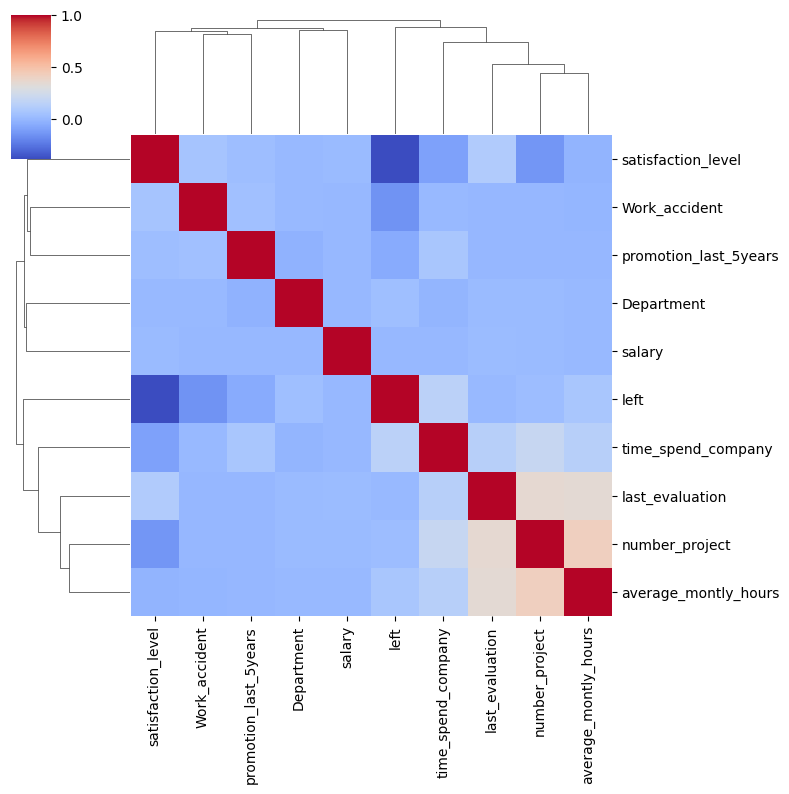

In [5]:
#do heatmap and correlation map. Cos very fun
HR_for_corr = HR_data
le = LabelEncoder()
HR_for_corr['Department'] = le.fit_transform(HR_for_corr['Department'])
HR_for_corr['salary'] = le.fit_transform(HR_for_corr['salary'])
print(HR_for_corr)
corr = sns.clustermap(HR_for_corr.corr(), cmap='coolwarm', figsize=(8,8))

In [6]:
"""
Gatherings based on visualization.
Trends:
1. There seems to be a gap between average working hours between employees still working in the company
and those whom are not. Correlation may be present between hours worked vs staying in company across ALL departments
2. There seems to be more goers in positions with lower salaries, but there is not much correlation i can see to expect that
lower positions will result in more departures
3. When it comes to satisfaction, there is definitely a relation to leaving and staying. People who stayed are much more
4. There seems to be a pattern where if an individual works for more than 7 years (i.e. 8 and above) THEY WILL NOT LEAVE
4.1 The rest seems to be a inconclusive trend whereby 1 year and below has good retention rate. It turns bad at the 5 year mark and then decrease again
5. for evaluation last, mean for those who left seems to be higher than those who stayed. But inconclusive
6. Work accident seems not to be a big factor in leaving.
"""

'\nGatherings based on visualization.\nTrends:\n1. There seems to be a gap between average working hours between employees still working in the company\nand those whom are not. Correlation may be present between hours worked vs staying in company across ALL departments\n2. There seems to be more goers in positions with lower salaries, but there is not much correlation i can see to expect that\nlower positions will result in more departures\n3. When it comes to satisfaction, there is definitely a relation to leaving and staying. People who stayed are much more\n4. There seems to be a pattern where if an individual works for more than 7 years (i.e. 8 and above) THEY WILL NOT LEAVE\n4.1 The rest seems to be a inconclusive trend whereby 1 year and below has good retention rate. It turns bad at the 5 year mark and then decrease again\n5. for evaluation last, mean for those who left seems to be higher than those who stayed. But inconclusive\n6. Work accident seems not to be a big factor in l

In [7]:
"""
Model Prediction
Dependent variable, variable to be tested will definitely be if a person will leave a company.
Based on what independent factors of course
1. Satisfaction level, this is quite ok to be used. Although variation is present for satisfaction levels for people who left,
but in general, people who stayed still have quite high satisfaction scores. Need to get the mean number of course.
2. Average working hours. 
3. Not sure if can set parameter of the model to see if number of years is more than 7, then immediately predict that they will stay
4. Might see if adding years worked in company will be effective. Since up till 5 years, retention rate decreases, then increases again
"""

"""Things to take note
1. Predictor values for dataset seem to be imbalanced.
Good to include imbalancing protocol.

"""

'Things to take note\n1. Predictor values for dataset seem to be imbalanced.\nGood to include imbalancing protocol.\n\n'

In [25]:
#import packages for modelling
"""Models considered: Tree (Decision Trees or Random Forest), See if can try Boosting Algorithms as well"""
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate, RandomizedSearchCV, StratifiedKFold
from sklearn.feature_selection import RFE, RFECV, SequentialFeatureSelector, SelectFromModel
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.combine import SMOTEENN


In [36]:
#Doing a decision tree classifier
feature_cols = ['satisfaction_level', 'promotion_last_5years', 'average_montly_hours', 'salary']
feature_cols_op = ['satisfaction_level', 'average_montly_hours']
X = HR_for_corr[feature_cols_op]
y = HR_for_corr['left']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=4202)

sm = RandomOverSampler(random_state = 42)
X_res, y_res = sm.fit_resample(X_train, y_train)
clf = DecisionTreeClassifier(class_weight='balanced')
clf2 = clf.fit(X_res, y_res)
y_pred = clf2.predict(X_test)


probs = clf2.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, probs)

# Find threshold that gives you the precision you want (e.g. >= 0.9)
import numpy as np
target_precision = 0.9
idxs = np.where(precision[:-1] >= target_precision)[0]  # precision[:-1] to match thresholds length

if len(idxs) == 0:
    idx = np.argmax(precision[:-1])  # pick best achievable precision
else:
    idx = idxs[0]

best_thresh = thresholds[idx]
#print(f"Threshold achieving ~{target_precision:.2f} precision: {best_thresh:.3f}")

# Apply new threshold
y_pred_adj = (probs >= best_thresh).astype(int)

print(metrics.accuracy_score(y_test, y_pred))
print(metrics.accuracy_score(y_test, y_pred_adj))

0.9204444444444444
0.9055555555555556


In [32]:
#checking confusion matrix and classification report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

"""
According to results
Still a decent size of false positives.
precision for 1 is still lower.

"""

[[3173  228]
 [ 126  973]]
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      3401
           1       0.81      0.89      0.85      1099

    accuracy                           0.92      4500
   macro avg       0.89      0.91      0.90      4500
weighted avg       0.92      0.92      0.92      4500



'\nAccording to results\nStill a decent size of false positives.\nprecision for 1 is still lower.\n\n'

In [37]:
#finding out the right or suitable hyperparameters to set for decision tree
"""
Parameters to consider
1. max_depth - maybe set a range for 3 to 10
2. min_samples_split - maybe set a 2, 10, 20, 30, 40
3. min_samples_leaf - set a 3, 5, 10, 25 as recommended
4. max_features - set a 2 and 3 ba
5. min_weight_fraction_leaf - 0.1 to 0.5 (with 0.1 gap)
"""

param_grid = {
    "criterion":['gini', 'entropy', 'log_loss'],
    "max_depth": [None,1,3,5,10,15,20],
    "min_samples_split": [2,5,10,20,50],
    "min_samples_leaf": [1,2,5,10,20],
    "class_weight":[None, 'balanced']

}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=param_grid, cv=cv, scoring='precision')
grid_search.fit(X_train, y_train)
best_parameters = grid_search.best_params_
best_clf = grid_search.best_estimator_

In [ ]:
#taking the parameters and best estimator accuracy based on the above Decision Tree param grid
best_y_pred = best_clf.predict(X_test)
print(metrics.accuracy_score(y_test, best_y_pred))
print(best_parameters)

0.9175555555555556
{'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 50}


In [39]:
#Might want to do a random forest classifier next
rf = RandomForestClassifier(class_weight={0:1, 1:0.5})
rf2 = rf.fit(X_res, y_res)
y_pred = rf2.predict(X_test)
print(metrics.accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


0.9248888888888889
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      3401
           1       0.83      0.87      0.85      1099

    accuracy                           0.92      4500
   macro avg       0.89      0.91      0.90      4500
weighted avg       0.93      0.92      0.93      4500



In [40]:
#updated random forest
rf_updated = RandomForestClassifier(
    n_estimators=500, 
    max_depth=None,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features='sqrt',
    class_weight={0:1, 1:0.5},
    n_jobs=1,
    random_state=1010)
#try to see if managing the data features themselves will work
selector = SelectFromModel(RandomForestClassifier(random_state=42))
selector.fit(X_train, y_train)
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)
sm = RandomOverSampler(random_state = 42)
X_res, y_res = sm.fit_resample(X_train_sel, y_train)

rf_updated = rf_updated.fit(X_res, y_res)
mod_y_pred = rf_updated.predict(X_test_sel)
print(classification_report(y_test, mod_y_pred))
print(metrics.accuracy_score(y_test, mod_y_pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93      3401
           1       0.85      0.70      0.77      1099

    accuracy                           0.90      4500
   macro avg       0.88      0.83      0.85      4500
weighted avg       0.89      0.90      0.89      4500

0.8955555555555555


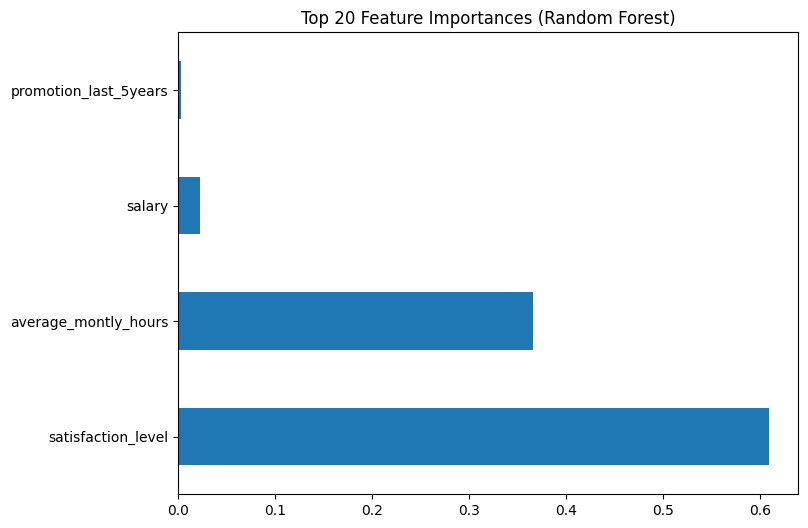

In [30]:
#checking which features are important and which are noise
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feat_imp.head(20).plot(kind='barh')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.show()

In [ ]:
#try to tune hyperparameters again
param_grid = {
    'n_estimators': [200,300],
    'max_depth':[None,1,2,3,5,10],
    'min_samples_leaf':[5,10,20],
    'class_weight':[None, 'balanced'],
    'criterion':['gini', 'entropy', 'log_loss'],
    'max_samples':[0.1,0.2]
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=1010)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, scoring='precision', cv=cv)
grid_search.fit(X_res, y_res)
best_rf = grid_search.best_estimator_
best_rf_ypred = best_rf.predict(X_test)
print(metrics.accuracy_score(y_test, best_rf_ypred))
print(classification_report(y_test, best_rf_ypred))

0.8948888888888888
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      3401
           1       0.73      0.90      0.81      1099

    accuracy                           0.89      4500
   macro avg       0.85      0.90      0.87      4500
weighted avg       0.91      0.89      0.90      4500



In [18]:
print(grid_search.best_params_)

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_samples': 0.2, 'min_samples_leaf': 5, 'n_estimators': 300}


In [ ]:
"""Gatherings from modeling using Decision Tree and Random Forest"""
"""
1. Both Trees performs at their max in their natural settings
2. Seems like features importance does not really affect accuracy
3. Doing param grid of important features does seem to reduce the precision of 1 (Left) values
"""

In [57]:
#Time to do an AdaBoost or XGBoost
from xgboost import XGBClassifier


X = HR_for_corr[feature_cols] #just take all ba. Removing the other 2 does not make accuracy better
y = HR_for_corr['left']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=4202)
sm = RandomOverSampler(random_state = 42)
X_res, y_res = sm.fit_resample(X_train, y_train)


xgb = XGBClassifier(
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth = 9,
    min_child_weight = 1,
    subsample = 0.8,
    colsample_bytree = 0.8,
    gamma = 0,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state= 1010
)

xgb = xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
print(classification_report(y_test, y_pred))
print(y_pred)

              precision    recall  f1-score   support

           0       0.97      0.92      0.94      3401
           1       0.78      0.92      0.84      1099

    accuracy                           0.92      4500
   macro avg       0.88      0.92      0.89      4500
weighted avg       0.92      0.92      0.92      4500

[1 1 1 ... 0 0 0]


In [76]:
param_test1 = {
 'max_depth':range(3,10,2),
 'min_child_weight':range(1,6,2)
}

"""gsearch1 = GridSearchCV(estimator = XGBClassifier( learning_rate =0.1, n_estimators=300, max_depth=9,
 min_child_weight=1, gamma=0, subsample=0.8, colsample_bytree=0.8,
 objective= 'binary:logistic', scoring='roc_auc', nthread=4, scale_pos_weight=1, seed=27, iid=False), 
 param_grid = param_test1,n_jobs=4, cv=5)
gsearch1.fit(X_train,y_train)
gsearch1.best_params_, gsearch1.best_score_


param_test2 = {
 'max_depth':[8,9,10],
 'min_child_weight':[None,1,2]
}
gsearch2 = GridSearchCV(estimator = XGBClassifier(learning_rate=0.1, n_estimators=300, max_depth=9,
 min_child_weight=2, gamma=0, subsample=0.8, colsample_bytree=0.8,
 objective= 'binary:logistic', nthread=4, scale_pos_weight=1,seed=27, iid=False), 
 param_grid = param_test2, scoring='roc_auc',n_jobs=4,cv=5)
gsearch2.fit(X_train,y_train)
gsearch2.best_params_, gsearch2.best_score_


param_test2b = {
 'min_child_weight':[0,2,4,6]
}
gsearch2b = GridSearchCV(estimator = XGBClassifier( learning_rate=0.1, n_estimators=300, max_depth=8,
 min_child_weight=2, gamma=0, subsample=0.8, colsample_bytree=0.8,
 objective= 'binary:logistic', nthread=4, scale_pos_weight=1,seed=27, iid=False), 
 param_grid = param_test2b, scoring='roc_auc',n_jobs=4, cv=5)
gsearch2b.fit(X_train, y_train)
gsearch2b.best_params_, gsearch2b.best_score_

param_test3 = {
 'gamma':[i/10.0 for i in range(0,5)]
}
gsearch3 = GridSearchCV(estimator = XGBClassifier( learning_rate =0.1, n_estimators=300, max_depth=8,
 min_child_weight=None, gamma=0, subsample=0.8, colsample_bytree=0.8,
 objective= 'binary:logistic', nthread=4, scale_pos_weight=1,seed=27, iid=False), 
 param_grid = param_test3, scoring='roc_auc',n_jobs=4,cv=5)
gsearch3.fit(X_train, y_train)
gsearch3.best_params_, gsearch3.best_score_
"""

param_test4 = {
 'subsample':[i/10.0 for i in range(6,10)],
 'colsample_bytree':[i/10.0 for i in range(6,10)]
}
gsearch4 = GridSearchCV(estimator = XGBClassifier( learning_rate =0.1, n_estimators=300, max_depth=8,
 min_child_weight=None, gamma=0.3, subsample=0.8, colsample_bytree=0.8,
 objective= 'binary:logistic', nthread=4, scale_pos_weight=1,seed=27, iid=False), 
 param_grid = param_test4, scoring='roc_auc',n_jobs=4,cv=5)
gsearch4.fit(X_train, y_train)
gsearch4.best_params_, gsearch4.best_score_

param_test5 = {
 'subsample':[i/100.0 for i in range(75,90,5)],
 'colsample_bytree':[i/100.0 for i in range(75,90,5)]
}
gsearch5 = GridSearchCV(estimator = XGBClassifier( learning_rate =0.1, n_estimators=300, max_depth=8,
 min_child_weight=None, gamma=0.3, subsample=0.9, colsample_bytree=0.8,
 objective= 'binary:logistic', nthread=4, scale_pos_weight=1,seed=27, iid=False), 
 param_grid = param_test5, scoring='roc_auc',n_jobs=4,cv=5)
gsearch5.fit(X_train, y_train)
gsearch5.best_params_, gsearch5.best_score_

param_test6 = {
 'reg_alpha':[1e-5, 1e-2, 0.1, 1, 100]
}
gsearch6 = GridSearchCV(estimator = XGBClassifier( learning_rate =0.1, n_estimators=300, max_depth=8,
 min_child_weight=None, gamma=0.3, subsample=0.85, colsample_bytree=0.75,
 objective= 'binary:logistic', nthread=4, scale_pos_weight=1,seed=27, iid=False), 
 param_grid = param_test6, scoring='roc_auc',n_jobs=4,cv=5)
gsearch6.fit(X_train, y_train)
gsearch6.best_params_, gsearch6.best_score_

param_test7 = {
 'reg_alpha':[0, 0.00001, 0.00005, 0.0001, 0.0005]
}
gsearch7 = GridSearchCV(estimator = XGBClassifier( learning_rate =0.1, n_estimators=300, max_depth=8,
 min_child_weight=None, gamma=0.3, subsample=0.85, colsample_bytree=0.75,
 objective= 'binary:logistic', nthread=4, scale_pos_weight=1,seed=27, iid=False), 
 param_grid = param_test7, scoring='roc_auc',n_jobs=4,cv=5)
gsearch7.fit(X_train, y_train)
gsearch7.best_params_, gsearch7.best_score_


({'reg_alpha': 0.0001}, np.float64(0.9643963646010288))

In [85]:
#after tuning all other parameters. Adjust learning rate and no. estimators
##always lower learning rate and increase estimator parameters as a guideline
param_test7 = {
 'reg_alpha':[0.0001]
}
finalxgb = GridSearchCV(estimator = XGBClassifier( learning_rate =0.05, n_estimators=400, max_depth=8,
 min_child_weight=None, gamma=0.3, subsample=0.85, colsample_bytree=0.75,
 objective= 'binary:logistic', nthread=4, scale_pos_weight=1,seed=27, iid=False), 
 param_grid = param_test7, scoring='roc_auc',n_jobs=4,cv=5)
finalxgb.fit(X_train, y_train)
print('Best Grid Search Parameters :',finalxgb.best_params_)
print('Best Grid Search Score : ',finalxgb.best_score_)


Best Grid Search Parameters : {'reg_alpha': 0.0001}
Best Grid Search Score :  0.9643987780211797


In [ ]:
"""Summary of used classification models"""
"""
1. Trees (Decision Tree and Random Forest) are good in natural state
1.1 Accuracy for both lays around 9.32.
2. XGBoost works much better than Trees, especially when parameters for XGBoost are uptaken.
2.1 Best accuracy for current data is 9.64
3. Features are selected based on visualization. Their importance is rather low overall. But these factors are understood to play a factor already.
"""